In [6]:
!python -m pip install torch torchvision torchaudio

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the 'c:\Users\amrel\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [9]:
!python -m pip install --upgrade pip

  Attempting uninstall: pip
    Found existing installation: pip 20.2.3
    Uninstalling pip-20.2.3:
      Successfully uninstalled pip-20.2.3


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [10]:
!python -m pip install torch 

In [12]:
!python -m pip install numpy pandas matplotlib seaborn

   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
    --------------------------------------- 0.3/11.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.4 MB 1.7 MB/s eta 0:00:07
   --- ------------------------------------ 1.0/11.4 MB 2.0 MB/s eta 0:00:06
   ----- ---------------------------------- 1.6/11.4 MB 2.3 MB/s eta 0:00:05
   -------- ------------------------------- 2.4/11.4 MB 2.4 MB/s eta 0:00:04
   ---------- ----------------------------- 2.9/11.4 MB 2.5 MB/s eta 0:00:04
   ------------ --------------------------- 3.4/11.4 MB 2.6 MB/s eta 0:00:04
   -------------- ------------------------- 4.2/11.4 MB 2.6 MB/s eta 0:00:03
   ---------------- ----------------------- 4.7/11.4 MB 2.7 MB/s eta 0:00:03
   ------------------ --------------------- 5.2/11.4 MB 2.7 MB/s eta 0:00:03
   --------------------- ------------------ 6.0/11.4 MB 2.7 MB/s eta 0:00:02
   ----------------------- ---------------- 6.6/11.4 MB 2.7 MB/s eta 0:00:02
   ----------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [13]:
from torchvision import datasets, transforms

In [16]:
import torch
import torch.nn as nn

In [28]:
import numpy as np
import pandas as pd

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
train_val_dataset = datasets.MNIST(root="./datasets/", train=True, download=True)
test_dataset = datasets.MNIST(root="./datasets/", train=False, download=True)

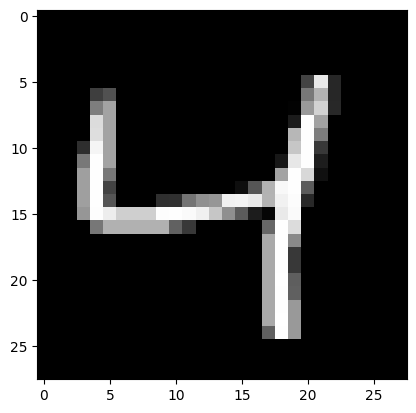

In [32]:
plt.imshow(train_val_dataset.data[2], cmap="gray")

In [34]:
train_val_dataset.targets[2]
#data and targets are stored in the data and targets attributes of the dataset, respectively.

tensor(4)

In [35]:
def img_pixel_superimpose(img, ax):
    w, h = img.shape
    color_map = plt.cm.get_cmap('gray_r')  # gray_reversed
    ax.imshow(img, cmap='gray')
    for x in range(w):
        for y in range(h):
            color = color_map(img[x][y])
            ax.annotate(str(img[x][y]), xy=(y,x), horizontalalignment='center', verticalalignment='center',
                        color=color)
            plt.axis(False)

In [36]:
train_val_dataset = datasets.MNIST(root="./datasets/", train=True, download=False, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root="./datasets", train=False, download=False, transform=transforms.ToTensor())
train_val_dataset, test_dataset

(Dataset MNIST
     Number of datapoints: 60000
     Root location: ./datasets/
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: ./datasets
     Split: Test
     StandardTransform
 Transform: ToTensor())

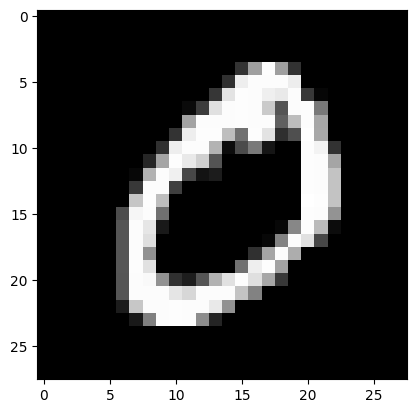

In [40]:
plt.imshow(train_val_dataset.data[1], cmap="gray")

In [48]:
imgs = torch.stack([img for img, _ in train_val_dataset], dim=0)

In [49]:
mean = imgs.view(1, -1).mean(dim=1)    # or imgs.mean()
std = imgs.view(1, -1).std(dim=1)     # or imgs.std()

torch.Size([60000, 1, 28, 28])

In [43]:
train_val_dataset.data.shape, test_dataset.data.shape

(torch.Size([60000, 28, 28]), torch.Size([10000, 28, 28]))

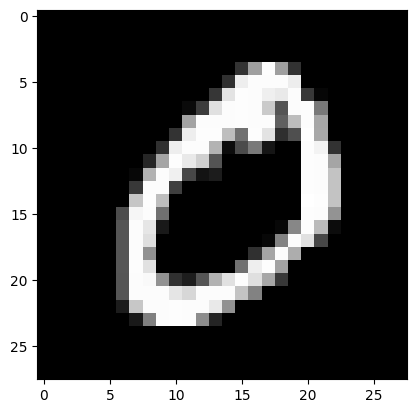

In [47]:
plt.imshow(imgs[1][0], cmap="gray")
